In [1]:
#activate venv: 
import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 34 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = ['minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'assists', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles',
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > current_gw
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 31.02 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155525 entries, 0 to 155524
Columns: 454 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(449), object(5)
memory usage: 538.7+ MB
None


In [4]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 310 potential features:
Total rows: 43567

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                           tackles_elo_p90sq_3      37363    85.76            6204
                               tackles_p90sq_3      37363    85.76            6204
                               cbi_elo_p90sq_3      37363    85.76            6204
                                   cbi_p90sq_3      37363    85.76            6204
                            recoveries_p90sq_3      37363    85.76            6204
                        recoveries_elo_p90sq_3      37363    85.76            6204
                        defensive_cont_p90sq_3      37363    85.76            6204
                    defensive_cont_elo_p90sq_3      37363    85.76            6204
                        recoveries_elo_p90sq_5      37305    85.63            6262
                            recoveries_p90sq_5      37305    85

In [5]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [6]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [7]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [8]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [9]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

In [10]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    # FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    # MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    # DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    # GK_mins_predictor.plot_results()

Cleaned df size: 2752/8095

Training Set Performance:
R² Score: 0.8220
RMSE: 13.8351
MAE: 11.4628

Test Set Performance:
R² Score: 0.4166
RMSE: 25.0210
MAE: 20.3916

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.291591
    opp_team_elo_p90sq_3    0.039750
    opp_team_elo_p90sq_5    0.036884
           minutes_elo_3    0.022871
       team_elo_p90sq_at    0.011703
        team_elo_p90sq_3    0.009542
          opp_team_elo_5    0.009034
   opp_team_elo_p90sq_at    0.008876
       team_elo_p90sq_10    0.008731
   clean_sheets_p90sq_at    0.008680
                elo_diff    0.008467
        team_elo_p90sq_5    0.008210
            bps_p90sq_at    0.008160
            opp_team_elo    0.007797
                team_elo    0.007116
         opp_team_elo_10    0.006575
opp_team_elo_elo_p90sq_5    0.006539
 goals_conceded_p90sq_at    0.006470
   opp_team_elo_p90sq_10    0.005918
         goals_scored_10    0.005842
Cleaned df size: 9485/30112



In [11]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    # FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    # MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    # DEF_xG_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2822/4657

Training Set Performance:
R² Score: 0.6141
RMSE: 0.2390
MAE: 0.1925

Test Set Performance:
R² Score: 0.0451
RMSE: 0.3898
MAE: 0.2961

Top 20 Feature Importances:
                 feature  importance
   goals_scored_p90sq_at    0.042871
                elo_diff    0.042755
         xg_over_g_ratio    0.027645
          opp_team_elo_3    0.019058
            opp_team_elo    0.018975
          bonus_p90sq_at    0.018739
        team_elo_p90sq_3    0.018666
         opp_team_elo_10    0.015621
    opp_team_elo_p90sq_3    0.013454
          opp_team_elo_5    0.012389
        assists_p90sq_at    0.011821
        team_elo_p90sq_5    0.010328
 goals_conceded_p90sq_at    0.010152
    goals_conceded_elo_3    0.009483
total_points_elo_p90sq_5    0.009123
    opp_team_elo_p90sq_5    0.009044
              assists_at    0.009013
          assists_p90_at    0.008886
     minutes_elo_p90sq_3    0.008829
       team_elo_p90sq_at

In [12]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    # FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    # MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    # DEF_xA_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 3028/4960

Training Set Performance:
R² Score: 0.6318
RMSE: 0.0724
MAE: 0.0492

Test Set Performance:
R² Score: 0.0327
RMSE: 0.1176
MAE: 0.0700

Top 20 Feature Importances:
                feature  importance
                assists    0.125050
           opp_team_elo    0.043958
         assists_elo_10    0.034413
   goals_conceded_elo_3    0.018187
         opp_team_elo_3    0.017529
     assists_elo_p90_10    0.013768
         opp_team_elo_5    0.012034
        opp_team_elo_10    0.011829
   total_points_p90sq_3    0.010475
        xg_over_g_ratio    0.010252
  goals_conceded_elo_10    0.009783
              assists_3    0.009592
               elo_diff    0.009512
       goals_conceded_3    0.009111
  goals_scored_p90sq_at    0.008813
    minutes_elo_p90sq_5    0.008800
       bps_elo_p90sq_10    0.008592
              bps_p90_5    0.008537
opp_team_elo_elo_p90_10    0.008450
   total_points_p90sq_5    0.008437
target

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    # FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    # MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    # DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    # GK_xGC_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 3028/4960

Training Set Performance:
R² Score: 0.6692
RMSE: 0.5254
MAE: 0.4258

Test Set Performance:
R² Score: 0.1666
RMSE: 0.8546
MAE: 0.6629

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.165043
               opp_team_elo    0.032933
            xg_over_g_ratio    0.028663
            opp_team_elo_10    0.021121
             opp_team_elo_5    0.016315
      clean_sheets_p90sq_at    0.014231
    goals_conceded_p90sq_at    0.014099
             assists_p90_at    0.012326
           assists_p90sq_at    0.011540
             opp_team_elo_3    0.010659
                team_elo_10    0.010574
      total_points_p90sq_at    0.009417
      opp_team_elo_p90sq_at    0.008484
          team_elo_p90sq_at    0.008201
      goals_conceded_elo_10    0.008022
goals_conceded_elo_p90sq_10    0.008001
      goals_conceded_p90_10    0.007982
         minutes_elo_p90_10    0.0

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    # FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    # MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    # DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    # GK_bps_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4440/4960

Training Set Performance:
R² Score: 0.5076
RMSE: 12.9875
MAE: 10.3402

Test Set Performance:
R² Score: 0.0964
RMSE: 17.2203
MAE: 13.1753

Top 20 Feature Importances:
                feature  importance
                assists    0.179776
               elo_diff    0.053890
           opp_team_elo    0.024976
        opp_team_elo_10    0.019106
         opp_team_elo_5    0.017361
         opp_team_elo_3    0.014576
goals_conceded_p90sq_at    0.011509
   minutes_elo_p90sq_10    0.010516
         bonus_p90sq_at    0.009252
           bps_p90sq_at    0.008439
            bps_p90sq_5    0.008272
       assists_p90sq_at    0.008199
  total_points_p90sq_at    0.008110
 clean_sheets_elo_p90_5    0.007854
             bps_elo_10    0.007786
     minutes_elo_p90_10    0.007600
    minutes_elo_p90sq_3    0.006974
        bps_elo_p90sq_5    0.006920
   goals_conceded_elo_3    0.006823
   opp_team_elo_p90sq_5    0.006714
target=bps_per

In [15]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    # GK_saves_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 4157/4432

Training Set Performance:
R² Score: 0.5434
RMSE: 1.3143
MAE: 1.0633

Test Set Performance:
R² Score: 0.0563
RMSE: 1.9124
MAE: 1.5085

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.153673
               opp_team_elo    0.021151
             saves_p90sq_at    0.018519
    goals_conceded_p90sq_at    0.015339
               bps_p90sq_at    0.015164
      opp_team_elo_p90sq_at    0.015060
             opp_team_elo_5    0.014492
          team_elo_p90sq_at    0.014221
             saves_p90sq_10    0.013611
            opp_team_elo_10    0.013475
   total_points_elo_p90sq_3    0.012412
       opp_team_elo_p90sq_5    0.011789
          saves_elo_p90sq_5    0.011254
         saves_elo_p90sq_10    0.011206
goals_conceded_elo_p90sq_10    0.010867
             opp_team_elo_3    0.010836
      total_points_p90sq_at    0.010658
              saves_p90sq_3    0.009952
   total_po

In [16]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    # FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    # MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    # DEF_defcon_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 750/5476

Training Set Performance:
R² Score: 0.7677
RMSE: 1.3880
MAE: 1.1083

Test Set Performance:
R² Score: 0.0463
RMSE: 3.0154
MAE: 2.2855

Top 20 Feature Importances:
                feature  importance
        xg_over_g_ratio    0.033312
             minutes_10    0.032179
  clean_sheets_p90sq_at    0.030684
goals_conceded_p90sq_at    0.021481
             assists_at    0.020417
         assists_p90_at    0.018315
           opp_team_elo    0.015952
               team_elo    0.014615
   total_points_p90sq_3    0.014367
       assists_p90sq_at    0.014296
         opp_team_elo_5    0.013778
        opp_team_elo_10    0.013633
         bonus_p90sq_at    0.013318
 goals_conceded_p90sq_3    0.012317
    minutes_elo_p90sq_5    0.012241
 goals_conceded_p90sq_5    0.012102
         opp_team_elo_3    0.011998
  goals_scored_p90sq_at    0.011876
             team_elo_3    0.011796
                  bps_3    0.0115

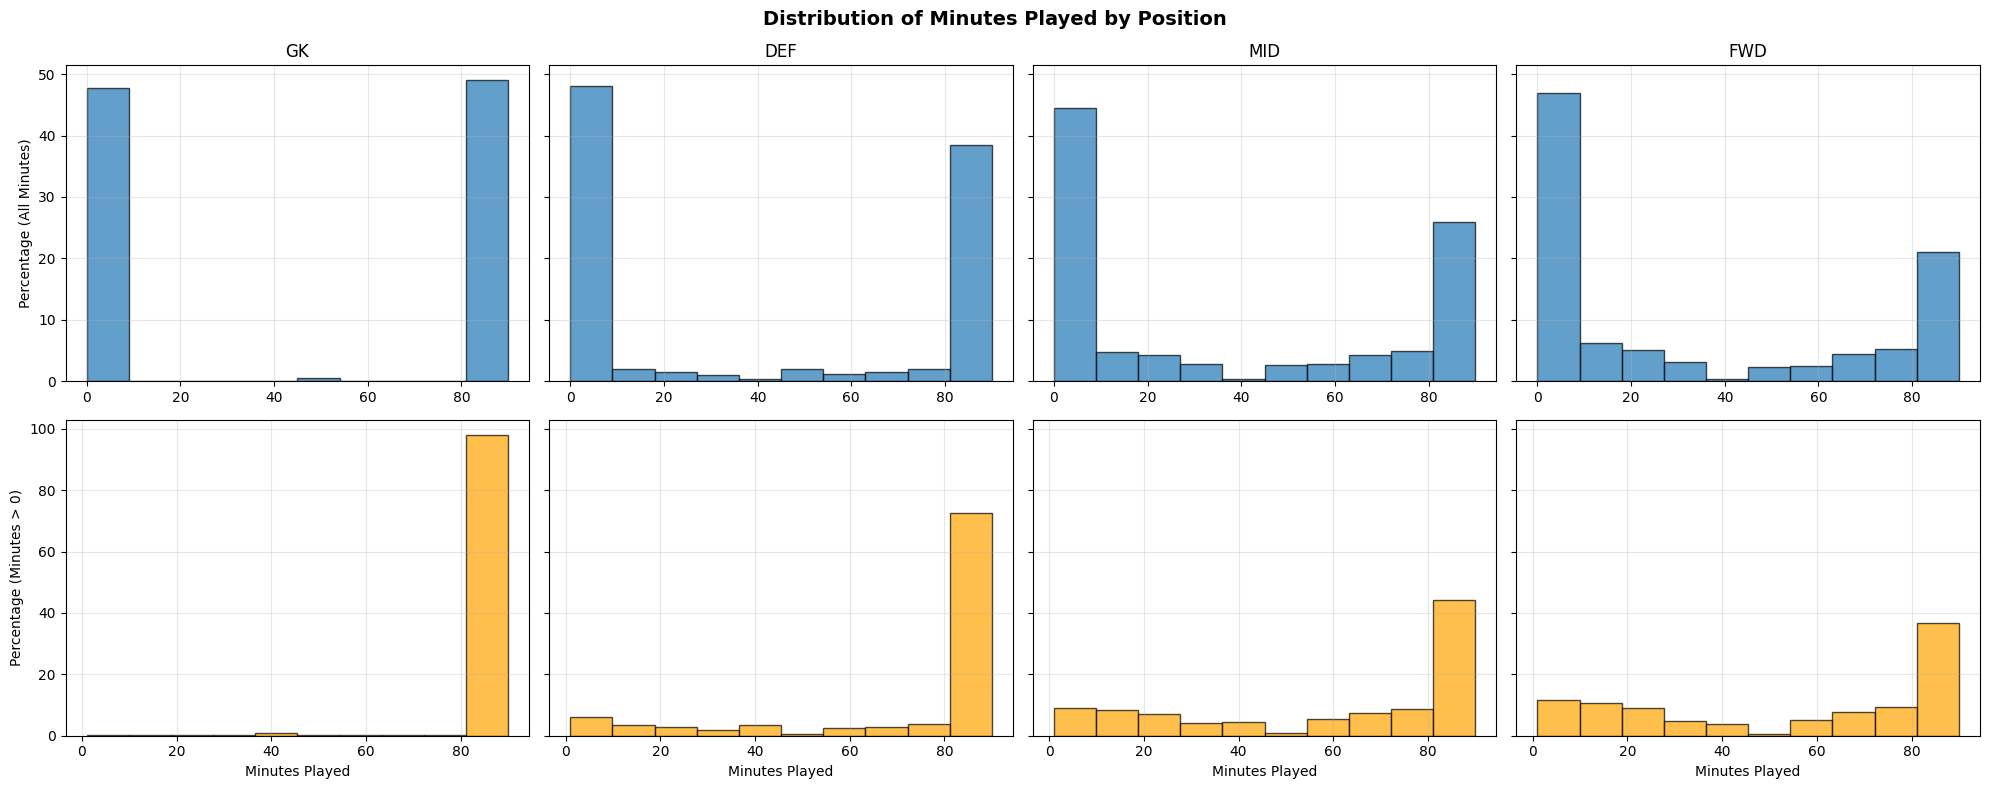

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.365


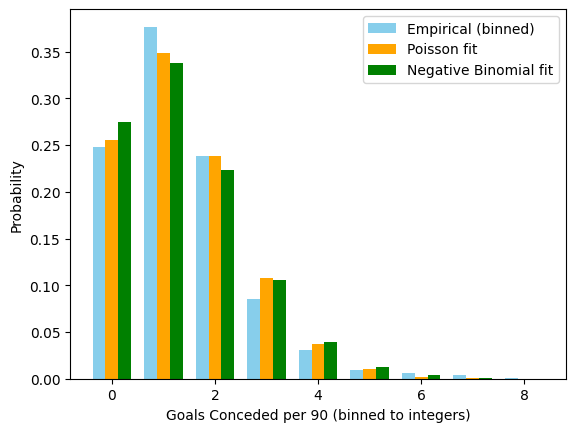

Mean: 1.355, Variance: 1.494
Overdispersion ratio (Var/Mean): 1.102
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.255


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.218


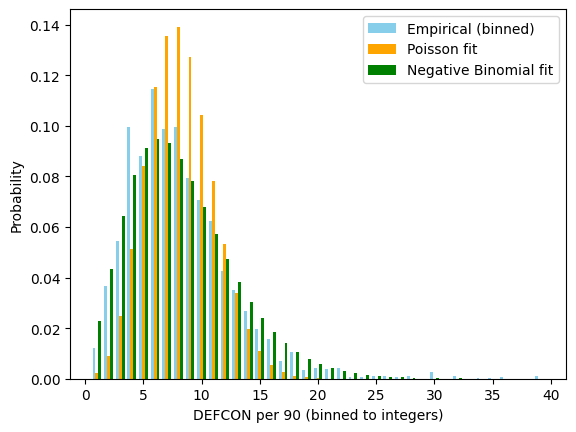

Mean: 8.210, Variance: 21.032
Overdispersion ratio (Var/Mean): 2.562
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [19]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.195


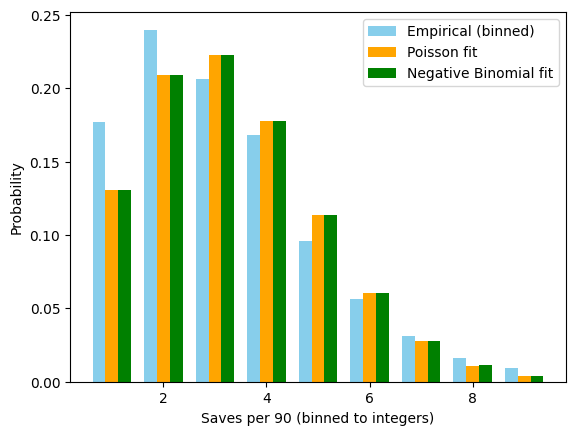

Mean: 3.195, Variance: 3.199
Overdispersion ratio (Var/Mean): 1.001
✅ Poisson assumption looks reasonable.


In [20]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [21]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=current_gw+1)]

In [22]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [23]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17992\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    1995.000000
mean       59.406422
std        21.668654
min        12.607602
25%        39.807429
50%        59.871637
75%        81.468113
max        89.926971
Name: mins_pred, dtype: float64

In [24]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17992\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    1850.000000
mean        0.159901
std         0.127700
min         0.028633
25%         0.058358
50%         0.121349
75%         0.213673
max         0.722028
Name: xgp90_pred, dtype: float64

In [25]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17992\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    1850.000000
mean        0.081679
std         0.058588
min         0.022005
25%         0.043538
50%         0.066993
75%         0.102789
max         0.408410
Name: xap90_pred, dtype: float64

In [26]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17992\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    1995.000000
mean        1.458109
std         0.348915
min         0.466071
25%         1.225175
50%         1.433069
75%         1.679456
max         2.633611
Name: xgcp90_pred, dtype: float64

In [27]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17992\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    1995.000000
mean       14.399477
std         3.045151
min         2.665690
25%        12.486499
50%        13.910400
75%        16.298398
max        26.245849
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.447
Model:                            OLS   Adj. R-squared (uncentered):              0.447
Method:                 Least Squares   F-statistic:                          3.714e+04
Date:                Tue, 28 Apr 2026   Prob (F-statistic):                        0.00
Time:                        08:58:37   Log-Likelihood:                         -43346.
No. Observations:               45949   AIC:                                  8.669e+04
Df Residuals:                   45948   BIC:                                  8.670e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

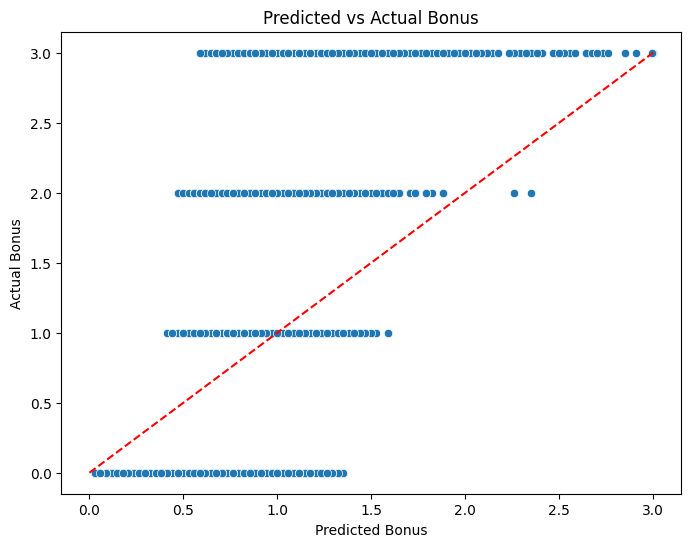

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459489  0.228044  1.107425  1.945865
FWD           0.330515  0.197804  1.046770  1.712907
GK            0.488521  0.244722  1.113078  2.009226
GKP                NaN       NaN       NaN       NaN
MID           0.397465  0.244336  1.050205  1.826927


C:\Users\Chris\AppData\Local\Temp\ipykernel_17992\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [28]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [29]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_17992\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [30]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17992\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    145.000000
mean       3.193876
std        0.705270
min        1.391079
25%        2.703574
50%        3.040201
75%        3.589362
max        5.555059
Name: xsavesp90_pred, dtype: float64

In [31]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17992\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    1850.000000
mean        7.943900
std         2.003755
min         3.217397
25%         6.595746
50%         8.099771
75%         9.452451
max        16.059425
Name: xdefconp90_pred, dtype: float64

In [32]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
135630,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,35.0,Bournemouth,1090.250199,64.093823,0.078694,0.102687,1.405994
135632,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,36.0,Everton,1055.499286,64.042895,0.079560,0.103319,1.405694
135634,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,37.0,Brentford,1063.653532,64.093823,0.079560,0.103319,1.414645
135636,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,38.0,Arsenal,1238.965057,63.888193,0.067238,0.100143,1.574066
135662,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,35.0,Brentford,1063.653532,21.088147,0.096751,0.061253,1.729063


In [33]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
140812,Erling Haaland,430.0,145.0,Man City,FWD,20252026.0,35.0,Everton,1055.499286,83.962266,0.712971,0.053492,1.073930
143692,Jonah Kusi-Asare,737.0,45.0,Fulham,FWD,20252026.0,35.0,Arsenal,1238.965057,27.764257,0.624364,0.149487,2.633611
154963,Wilson Isidor,560.0,50.0,Sunderland,FWD,20252026.0,35.0,Wolves,919.546389,16.952486,0.588273,0.053499,0.836576
139891,Enes Ünal,98.0,54.0,Bournemouth,FWD,20252026.0,35.0,Crystal Palace,1049.885135,19.258347,0.585023,0.047692,1.536012
139163,Eddie Nketiah,284.0,54.0,Crystal Palace,FWD,20252026.0,35.0,Bournemouth,1090.250199,37.382488,0.579150,0.089008,1.441352
145578,João Pedro Junqueira de Jesus,249.0,77.0,Chelsea,FWD,20252026.0,35.0,Nott'm Forest,1038.288405,63.719988,0.550842,0.090636,1.330485
136692,Arnaud Kalimuendo,696.0,60.0,Nott'm Forest,FWD,20252026.0,35.0,Chelsea,1085.739158,27.619448,0.548738,0.050554,1.374733
141402,Frank Onyeka,128.0,48.0,Brentford,MID,20252026.0,35.0,West Ham,1009.956491,31.421569,0.521132,0.243433,1.565070
138205,Callum Marshall,626.0,43.0,West Ham,FWD,20252026.0,35.0,Brentford,1063.653532,39.395983,0.519626,0.046700,1.286532
150757,Odsonne Édouard,285.0,50.0,Crystal Palace,FWD,20252026.0,35.0,Bournemouth,1090.250199,26.090804,0.510632,0.051746,1.462894


In [34]:
# -----------------------------------------------------------------------
# Build per-player overperformance factors from ALL historical data in df
# -----------------------------------------------------------------------
# stat_pairs: (actual_column, expected_column, output_key)
#   'xg' key  → will be applied to xgp90_pred
#   'xa' key  → will be applied to xap90_pred

from FPLStatOverperformanceAnalyzer import (
    FPLStatOverperformanceAnalyzer,
    build_player_adjustments,
    apply_adjustments,
)

overperf_adjustments = build_player_adjustments(
    df,
    stat_pairs=[
        ('goals_scored',  'expected_goals',   'xg'),
        ('assists',       'expected_assists',  'xa')],
    taper_k_90s=15.0, # 15 90s needed for 50% credibility (50% observed & 50% prior(1))
    only_if_significant=True, # only adjust if p < 0.05
    min_xstat=2.0, # need ≥2 cumulative xG/xA to run test
)

print(f"Computed adjustments for {len(overperf_adjustments)} players")

# Apply factors to prediction_data
#   - Saves original columns as xgp90_pred_raw / xap90_pred_raw
#   - Adds xg_overperf_factor / xa_overperf_factor columns for audit
prediction_data = apply_adjustments(
    prediction_data,
    overperf_adjustments,
    col_map={
        'xg': 'xgp90_pred',
        'xa': 'xap90_pred',
    },
)

# Show the adjustment for the next gameweek's top players
print(f"\nNext GW{current_gw + 1} Top Players with Overperformance Factors:")
(
    prediction_data[prediction_data['event'] == current_gw + 1]
    [['player_name_id','position', 'xg_overperf_factor', 'xa_overperf_factor',
      'xgp90_pred_raw', 'xgp90_pred',
      'xap90_pred_raw', 'xap90_pred']].groupby('player_name_id').agg({'position': 'first', 'xg_overperf_factor': 'mean', 'xa_overperf_factor': 'mean',
                                                                      'xgp90_pred_raw': 'mean', 'xgp90_pred': 'mean', 'xap90_pred_raw': 'mean', 'xap90_pred': 'mean'})
    .sort_values('xg_overperf_factor', ascending=False)
    .head(30))

Computed adjustments for 2611 players

Next GW35 Top Players with Overperformance Factors:


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOverperformanceAnalyzer.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[f"{col}_raw"]             = prediction_data[col].copy()
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOverperformanceAnalyzer.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[col]                      = prediction_data[col] * factors
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOv

,position,xg_overperf_factor,xa_overperf_factor,xgp90_pred_raw,xgp90_pred,xap90_pred_raw,xap90_pred
player_name_id,,,,,,,
Bernardo Mota Veiga de Carvalho e Silva,MID,4.686507,4.522283,0.119560,0.560318,0.170223,0.769796
Reece James,DEF,4.134913,2.956513,0.050969,0.210751,0.162514,0.480473
Mason Mount,MID,3.907183,5.260819,0.163282,0.637971,0.082020,0.431491
John Stones,DEF,3.577495,1.000000,0.223550,0.799750,0.049302,0.049302
Michael Keane,DEF,2.913623,1.000000,0.050809,0.148039,0.031163,0.031163
Youri Tielemans,MID,2.718499,2.298539,0.108588,0.295195,0.177961,0.409049
James Ward-Prowse,MID,2.527228,1.773605,0.162558,0.410822,0.139888,0.248106
Phil Foden,MID,2.508490,1.742554,0.203100,0.509474,0.134660,0.234653
Conor Gallagher,MID,2.508065,3.347728,0.092206,0.231258,0.053181,0.178037


In [35]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [36]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [37]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_17992\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_17992\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykerne

In [38]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event','fixture',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xg_overperf_factor', 'xa_overperf_factor','xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus','xpoints']]
fixture_predictions = predictions.copy()  # keep per-fixture detail
# Existing per-fixture xpoints are computed above
# Now aggregate to gameweek level by summing across fixtures within each event

predictions_by_gw = predictions.groupby(
    ['player_name_id', 'element', 'team_name', 'position', 'season', 'event', 'value'],
    as_index=False,
    dropna=False
).agg(
    # descriptive
    team_name=('team_name', 'first'),
    team_elo=('team_elo', 'first'),
    opp_team_name=('opp_team_name', lambda x: '; '.join(x.dropna())), # concatenate opponent names for multiple fixtures
    opp_team_elo=('opp_team_elo', 'mean'),
    position=('position', 'first'),
    value=('value', 'first'),
    #count fixtures to identify DGWs
    fixture_count=('fixture', 'count'),
    #sum points components across fixtures
    mins_pred=('mins_pred', 'sum'),
    xpoints=('xpoints', 'sum'),
    xpoints_mins=('xpoints_mins', 'sum'),
    xpoints_goals=('xpoints_goals', 'sum'),
    xpoints_assists=('xpoints_assists', 'sum'),
    xg_overperf_factor=('xg_overperf_factor', 'mean'),
    xa_overperf_factor=('xa_overperf_factor', 'mean'),
    xpoints_clean_sheets=('xpoints_clean_sheets', 'sum'),
    xpoints_shots_saved=('xpoints_shots_saved', 'sum'),
    xpoints_goals_conceded=('xpoints_goals_conceded', 'sum'),
    xpoints_defcon=('xpoints_defcon', 'sum'),
    xpoints_bonus=('xpoints_bonus', 'sum'),
    # rates average across fixtures
    xgp90_pred=('xgp90_pred', 'mean'),
    xap90_pred=('xap90_pred', 'mean'),
    xgcp90_pred=('xgcp90_pred', 'mean'),
)

predictions_by_gw[predictions_by_gw['player_name_id'].isna()]

,player_name_id,element,season,event,team_name,team_elo,opp_team_name,opp_team_elo,position,value,...,xg_overperf_factor,xa_overperf_factor,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xgp90_pred,xap90_pred,xgcp90_pred


In [39]:
#use for fixture-level analysis
table_name = "predictions_by_fixture"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=fixture_predictions)
    # preds = db_creator.table_to_df(table_name=table_name)
    # print(preds.info())

In [40]:
#use to make transfer decisions at gameweek level
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions_by_gw)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1995 entries, 0 to 1994
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          1995 non-null   object 
 1   element                 1995 non-null   float64
 2   season                  1995 non-null   float64
 3   event                   1995 non-null   float64
 4   team_name               1995 non-null   object 
 5   team_elo                1995 non-null   float64
 6   opp_team_name           1995 non-null   object 
 7   opp_team_elo            1995 non-null   float64
 8   position                1995 non-null   object 
 9   value                   1995 non-null   float64
 10  fixture_count           1995 non-null   float64
 11  mins_pred               1995 non-null   float64
 12  xpoints                 1995 non-null   float64
 13  xpoints_mins            1995 non-null   float64
 14  xpoints_goals           1995 non-null   

In [41]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS latest_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS latest_my_team INTEGER DEFAULT 0
""")

In [42]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

## Update flags to identify teams before the freehit
db_creator.execute_sql(f"""
    UPDATE predictions
    SET latest_any_team = 1
    WHERE element IN (
        SELECT p.element
        FROM fpl_picks p
        JOIN gw_summary s ON p.member = s.member AND s.event = {current_gw}
        WHERE 
            -- Scenario 1: Standard week for the member (not on Free Hit)
            (s.chip IS DISTINCT FROM 'freehit' AND p.gw = {current_gw})
            
            OR 
            
            -- Scenario 2: Member is on Free Hit (revert to previous week's squad)
            (s.chip = 'freehit' AND p.gw = {current_gw - 1})
    )
""")

## Using same logic as above, If I used freehit this gw, set latest_my_team to previous gw's team
db_creator.execute_sql(f"""
    UPDATE predictions
    SET latest_my_team = 1
    WHERE element IN (
        SELECT p.element
        FROM fpl_picks p
        JOIN gw_summary s ON p.member = s.member AND s.event = {current_gw}
        WHERE p.member = '{my_name}'
          AND (
            -- If you didn't Free Hit, take your current picks
            (s.chip IS DISTINCT FROM 'freehit' AND p.gw = {current_gw})
            
            OR 
            
            -- If you DID Free Hit, take your picks from the previous GW
            (s.chip = 'freehit' AND p.gw = {current_gw - 1})
          )
    )
""")



In [43]:
view = db_creator.run_sql(f"""SELECT event, member, chip
                          FROM gw_summary
                          WHERE chip = 'freehit'
                            AND event = {current_gw}
                            """)
view

,event,member,chip
0,34.0,Tommy Davies,freehit
1,34.0,Christakis Christodoulou,freehit
2,34.0,Oliver Carroll,freehit


In [44]:
view = db_creator.run_sql("""SELECT *
                          FROM fpl_picks
                          LEFT JOIN gw_summary ON fpl_picks.member = gw_summary.member
                            AND fpl_picks.gw = gw_summary.event
                          WHERE chip = 'freehit'
                            """)
view

,member,memberid,season,div,gw,pick,element,position,multiplier,is_captain,...,bank,value,event_transfers,event_transfers_cost,points_on_bench,member,memberid,chip,season,div
0,Christopher Harris,145486.0,20252026.0,1.0,15.0,15.0,116.0,15.0,0.0,False,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
1,Christopher Harris,145486.0,20252026.0,1.0,15.0,14.0,100.0,14.0,0.0,False,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
2,Christopher Harris,145486.0,20252026.0,1.0,15.0,13.0,256.0,13.0,0.0,False,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
3,Christopher Harris,145486.0,20252026.0,1.0,15.0,12.0,567.0,12.0,0.0,False,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
4,Christopher Harris,145486.0,20252026.0,1.0,15.0,11.0,430.0,11.0,2.0,True,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Ryan Boyce,4933105.0,20252026.0,1.0,33.0,5.0,84.0,5.0,1.0,False,...,134.0,1003.0,0.0,0.0,22.0,Ryan Boyce,4933105.0,freehit,20252026.0,1.0
191,Ryan Boyce,4933105.0,20252026.0,1.0,33.0,4.0,74.0,4.0,1.0,False,...,134.0,1003.0,0.0,0.0,22.0,Ryan Boyce,4933105.0,freehit,20252026.0,1.0
192,Ryan Boyce,4933105.0,20252026.0,1.0,33.0,3.0,411.0,3.0,2.0,True,...,134.0,1003.0,0.0,0.0,22.0,Ryan Boyce,4933105.0,freehit,20252026.0,1.0
193,Ryan Boyce,4933105.0,20252026.0,1.0,33.0,2.0,224.0,2.0,1.0,False,...,134.0,1003.0,0.0,0.0,22.0,Ryan Boyce,4933105.0,freehit,20252026.0,1.0


In [45]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, fixture_count, opp_team_name, opp_team_elo, xpoints, fixture_count
                            FROM predictions
                        WHERE season = 20252026 
                          AND event = 33
                          AND player_name_id = 'Cole Palmer'
                            """)
view

,player_name_id,team_name,team_elo,season,event,fixture_count,opp_team_name,opp_team_elo,xpoints,fixture_count


In [46]:
print(f"Gameweek {current_gw+1} Predictions")
predictions_by_gw[
    predictions_by_gw['event']==current_gw+1
].pivot_table(index=['player_name_id',"element",'event',"value","team_name","position"], values='xpoints', aggfunc='sum').reset_index().sort_values(by='xpoints', ascending=False).head(20)

Gameweek 35 Predictions


,player_name_id,element,event,value,team_name,position,xpoints
55,Bernardo Mota Veiga de Carvalho e Silva,416.0,35.0,62.0,Man City,MID,8.018148
246,John Stones,409.0,35.0,54.0,Man City,DEF,5.911592
384,Nico O'Reilly,411.0,35.0,51.0,Man City,DEF,5.795124
140,Erling Haaland,430.0,35.0,145.0,Man City,FWD,5.777682
227,Jarrod Bowen,624.0,35.0,77.0,West Ham,FWD,5.751798
201,Jack Grealish,419.0,35.0,63.0,Everton,MID,5.684507
32,Antoine Semenyo,82.0,35.0,82.0,Man City,MID,5.557559
223,James Ward-Prowse,614.0,35.0,56.0,Burnley,MID,5.486611
109,Declan Rice,21.0,35.0,72.0,Arsenal,MID,5.463042
518,Youri Tielemans,48.0,35.0,59.0,Aston Villa,MID,5.388216


In [47]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (predictions_by_gw['event']>=current_gw)&(predictions_by_gw['event']<=current_gw+5)
predictions_by_gw[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW35 - GW39


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
55,Bernardo Mota Veiga de Carvalho e Silva,248.380455,5.721456,7.772162,6.025083,1.160889,0.0,0.000000,1.539649,1.488610,23.707848
109,Declan Rice,343.447048,7.719866,6.360156,3.678013,1.833450,0.0,0.000000,2.052866,2.023340,23.667692
227,Jarrod Bowen,319.910927,7.521879,7.344594,5.351467,0.000000,0.0,0.000000,1.067150,1.884759,23.169849
201,Jack Grealish,197.597587,5.029613,7.809993,4.939586,0.943564,0.0,0.000000,2.052866,2.121653,22.897274
223,James Ward-Prowse,323.886318,7.562371,7.677291,2.630419,0.533781,0.0,0.000000,2.052866,1.586777,22.043503
165,Gabriel dos Santos Magalhães,345.028459,7.729992,1.282742,0.859520,7.666554,0.0,-0.740888,2.158687,2.298079,21.254686
365,Mohamed Salah,304.059184,7.328892,6.205178,2.825588,1.099088,0.0,0.000000,2.052866,1.704251,21.215863
340,Mathias Jensen,342.392818,7.712922,6.253045,2.168032,0.987771,0.0,0.000000,2.052866,1.948134,21.122770
53,Benjamin White,315.208867,7.468342,1.344055,0.749310,7.553580,0.0,-0.761488,2.158687,2.030297,20.542782
518,Youri Tielemans,300.492582,7.275509,4.858692,3.613081,1.019084,0.0,0.000000,2.052866,1.704502,20.523734


In [48]:
print("Rest of Season Predictions")
predictions_by_gw.groupby('player_name_id')[['team_name','opp_team_elo','mins_pred',
                                           'xpoints', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus'
                                           ]].agg({'team_name':'first','opp_team_elo':'mean','mins_pred':'mean','xpoints':'sum', 'xpoints_mins':'sum', 'xpoints_goals':'sum',
                                           'xpoints_assists':'sum', 'xpoints_clean_sheets':'sum',
                                           'xpoints_shots_saved':'sum','xpoints_goals_conceded':'sum','xpoints_defcon':'sum','xpoints_bonus':'sum'}
                                                  ).reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,team_name,opp_team_elo,mins_pred,xpoints,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus
55,Bernardo Mota Veiga de Carvalho e Silva,Man City,1081.077853,82.793485,23.707848,5.721456,7.772162,6.025083,1.160889,0.0,0.000000,1.539649,1.488610
109,Declan Rice,Arsenal,996.837452,85.861762,23.667692,7.719866,6.360156,3.678013,1.833450,0.0,0.000000,2.052866,2.023340
227,Jarrod Bowen,West Ham,1090.926890,79.977732,23.169849,7.521879,7.344594,5.351467,0.000000,0.0,0.000000,1.067150,1.884759
201,Jack Grealish,Everton,1072.444255,49.399397,22.897274,5.029613,7.809993,4.939586,0.943564,0.0,0.000000,2.052866,2.121653
223,James Ward-Prowse,Burnley,1072.794338,80.971580,22.043503,7.562371,7.677291,2.630419,0.533781,0.0,0.000000,2.052866,1.586777
165,Gabriel dos Santos Magalhães,Arsenal,996.837452,86.257115,21.254686,7.729992,1.282742,0.859520,7.666554,0.0,-0.740888,2.158687,2.298079
365,Mohamed Salah,Liverpool,1097.774143,76.014796,21.215863,7.328892,6.205178,2.825588,1.099088,0.0,0.000000,2.052866,1.704251
340,Mathias Jensen,Brentford,1119.734400,85.598204,21.122770,7.712922,6.253045,2.168032,0.987771,0.0,0.000000,2.052866,1.948134
53,Benjamin White,Arsenal,996.837452,78.802217,20.542782,7.468342,1.344055,0.749310,7.553580,0.0,-0.761488,2.158687,2.030297
518,Youri Tielemans,Aston Villa,1063.881409,75.123145,20.523734,7.275509,4.858692,3.613081,1.019084,0.0,0.000000,2.052866,1.704502


In [49]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [50]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [51]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            SUM(pg.total_points) AS total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    GROUP BY p.player_name_id, p.element, p.season, p.event,
             p.team_name, p.team_elo, p.position, p.value, p.in_any_team, p.in_my_team,p.latest_any_team, p.latest_my_team,
             p.opp_team_name, p.opp_team_elo, p.fixture_count,
             p.xpoints, p.xpoints_mins, p.xpoints_goals, p.xpoints_assists, p.xg_overperf_factor,p.xa_overperf_factor,
             p.xpoints_clean_sheets, p.xpoints_shots_saved, p.xpoints_goals_conceded,
             p.xpoints_defcon, p.xpoints_bonus,
             p.mins_pred, p.xgp90_pred, p.xap90_pred, p.xgcp90_pred,
             p.prediction_timestamp, p.prediction_gameweek
    Limit 0 -- no data yet, just create the table structure;
""")

In [52]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 1995 new predictions to predictions_allgws


In [53]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','season','event','fixture','total_points']][future_filter].head()

,player_name_id,season,event,fixture,total_points
159976,Erling Haaland,20252026.0,35.0,346.0,NaN


In [54]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=25)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].sort_values(by='event').head(10)

,player_name_id,event,season,total_points,minutes
192514,Erling Haaland,25.0,20252026.0,11.0,90.0
192515,Erling Haaland,26.0,20252026.0,5.0,45.0
192516,Erling Haaland,27.0,20252026.0,6.0,90.0
192517,Erling Haaland,28.0,20252026.0,0.0,0.0
192518,Erling Haaland,29.0,20252026.0,2.0,90.0
192519,Erling Haaland,30.0,20252026.0,2.0,90.0
192520,Erling Haaland,32.0,20252026.0,2.0,90.0
192521,Erling Haaland,33.0,20252026.0,6.0,90.0
192523,Erling Haaland,33.0,20252026.0,7.0,90.0
206216,Erling Haaland,35.0,20252026.0,NaN,NaN


In [55]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
19365,Erling Haaland,2026-01-27 11:00:04.422834,24.0,3.886675,NaN
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
...,...,...,...,...,...
143326,Erling Haaland,2026-04-21 14:55:57.587362,38.0,4.933701,NaN
145796,Erling Haaland,2026-04-21 15:23:39.013596,38.0,4.933701,NaN
13478,Erling Haaland,2026-01-05 18:33:33.065519,38.0,4.510429,NaN
141356,Erling Haaland,2026-04-21 10:57:13.932011,38.0,4.933701,NaN


In [56]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 34.0   3.418776
                                                          35.0   3.388855
                                                          36.0   3.436291
                                                          37.0   3.421387
                                                          38.0   3.397330
...                                                                   ...
2026-04-24 09:52:02.611970 33                  20252026.0 38.0   3.373287
2026-04-28 08:58:45.649947 34                  20252026.0 35.0   3.393865
                                                          36.0   3.404096
                                                          37.0   3.361398
                                                          38.0   3.375112

[204 rows x 1 columns]

In [57]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2425
2026-01-07 16:29:20.849190,10
2026-01-08 16:44:49.940956,10
2026-01-22 16:59:38.976316,15
2026-01-25 11:24:25.347489,5
2026-01-26 14:27:00.627006,2475
2026-01-27 11:00:04.422834,2480
2026-02-01 11:57:12.353330,2490
2026-02-02 13:38:00.840050,2505


In [58]:
filtered = (df_complete['player_name_id'] == 'Erling Haaland')&(
    df_complete['season']==20252026) & (df_complete['event']==current_gw+1)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points
13475,2026-01-05 18:33:33.065519,20,20252026.0,35.0,5.590598,NaN
16941,2026-01-26 14:27:00.627006,23,20252026.0,35.0,4.103325,NaN
23178,2026-01-27 11:00:04.422834,23,20252026.0,35.0,3.711646,NaN
30160,2026-02-01 11:57:12.353330,24,20252026.0,35.0,3.419905,NaN
37164,2026-02-02 13:38:00.840050,24,20252026.0,35.0,4.336733,NaN
44173,2026-02-03 14:41:19.430154,24,20252026.0,35.0,4.407095,NaN
50766,2026-02-09 12:29:03.939012,25,20252026.0,35.0,4.872502,NaN
56815,2026-02-13 13:00:38.658664,26,20252026.0,35.0,4.808286,NaN
62862,2026-02-19 17:56:20.307174,26,20252026.0,35.0,4.762019,NaN
68931,2026-02-20 10:52:25.776847,26,20252026.0,35.0,4.806728,NaN


In [59]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,20,20.000000
mean,2026-01-08 04:37:05.395072768,36.000000
min,2026-01-07 16:29:20.849190,34.000000
25%,2026-01-07 16:29:20.849189888,35.000000
50%,2026-01-08 04:37:05.395073024,36.000000
75%,2026-01-08 16:44:49.940955904,37.000000
max,2026-01-08 16:44:49.940956,38.000000
std,NaN,1.450953


In [60]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [61]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 33.17 minute(s)

Finished in 38.32 minute(s)


In [62]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)